
# Validación Cruzada - Vinos

**Validación cruzada en clasficación:** muestreo estratificado

**cv** = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cross_validate(model, X, Y, cv=cv, scoring=('f1', 'accuracy','precision', 'recall'), return_train_score=True)

- cv es el número de división (cuantos grupos)
- return_train_score=True -> devolver el resultado de la evaluación

## Objetivo del modelo

Predecir si un vino es de calidad **Buena** (nota de los catadores ≥ 6) o **Mala** (nota < 6) a partir de su análisis de laboratorio: 11 variables fisicoquímicas (acidez, azúcar, cloruros, sulfitos, densidad, pH, sulfatos, alcohol) y el tipo de vino (blanco o tinto). Es un problema de **clasificación binaria** con 4979 vinos.

In [1]:
# Cargamos librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparación de Datos


In [2]:
# Cargamos los datos
data = pd.read_csv("wine_data.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id,tipo,calidad
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1.0,tinto,Mala
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,2.0,tinto,Mala
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,3.0,tinto,Buena
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,4.0,tinto,Mala
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5.0,tinto,Mala


In [3]:
# Conocemos los datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4979 entries, 0 to 4978
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4979 non-null   float64
 1   volatile acidity      4979 non-null   float64
 2   citric acid           4979 non-null   float64
 3   residual sugar        4979 non-null   float64
 4   chlorides             4979 non-null   float64
 5   free sulfur dioxide   4979 non-null   float64
 6   total sulfur dioxide  4979 non-null   float64
 7   density               4979 non-null   float64
 8   pH                    4979 non-null   float64
 9   sulphates             4979 non-null   float64
 10  alcohol               4979 non-null   float64
 11  Id                    1018 non-null   float64
 12  tipo                  4979 non-null   object 
 13  calidad               4979 non-null   object 
dtypes: float64(12), object(2)
memory usage: 544.7+ KB


In [4]:
# Corrección del tipo de datos object a categorías
data['tipo']=data['tipo'].astype('category')
data['calidad']=data['calidad'].astype('category')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4979 entries, 0 to 4978
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         4979 non-null   float64 
 1   volatile acidity      4979 non-null   float64 
 2   citric acid           4979 non-null   float64 
 3   residual sugar        4979 non-null   float64 
 4   chlorides             4979 non-null   float64 
 5   free sulfur dioxide   4979 non-null   float64 
 6   total sulfur dioxide  4979 non-null   float64 
 7   density               4979 non-null   float64 
 8   pH                    4979 non-null   float64 
 9   sulphates             4979 non-null   float64 
 10  alcohol               4979 non-null   float64 
 11  Id                    1018 non-null   float64 
 12  tipo                  4979 non-null   category
 13  calidad               4979 non-null   category
dtypes: category(2), float64(12)
memory usage: 476.9 KB


In [5]:
# Variables irrelevantes
data = data.drop('Id',axis=1) # eliminamos el Id por ser irrelevante, axis=1 indica que es una columna
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,tipo,calidad
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,tinto,Mala
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,tinto,Mala
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,tinto,Buena
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,tinto,Mala
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,tinto,Mala


In [6]:
# Descripción de variables numéricas
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000
mean,7.135640,0.332267,0.320934,5.221621,0.054345,30.955312,118.614782,0.994385,3.219185,0.524386,10.561367
std,1.248562,0.160559,0.143151,4.585347,0.034388,17.804445,55.201299,0.002973,0.159831,0.143161,1.194316
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,6.400000,0.230000,0.250000,1.700000,0.037000,18.000000,84.000000,0.992000,3.110000,0.430000,9.500000
50%,6.900000,0.290000,0.310000,2.900000,0.046000,29.000000,120.000000,0.994400,3.210000,0.500000,10.400000
75%,7.600000,0.390000,0.390000,7.800000,0.060000,42.000000,157.000000,0.996600,3.320000,0.590000,11.400000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


<Axes: >

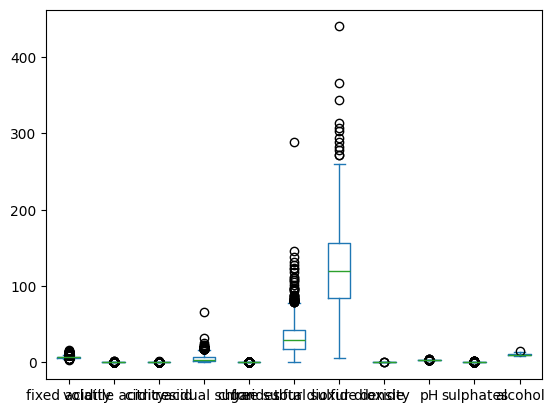

In [7]:
data.plot(kind='box')

<Axes: xlabel='tipo'>

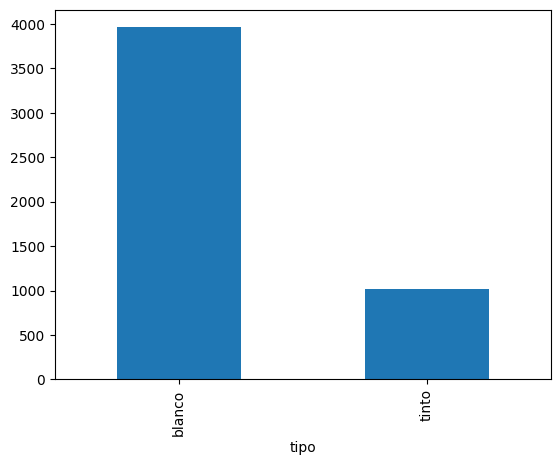

In [8]:
# Descripción variables categóricas
data['tipo'].value_counts().plot(kind='bar')

<Axes: ylabel='calidad'>

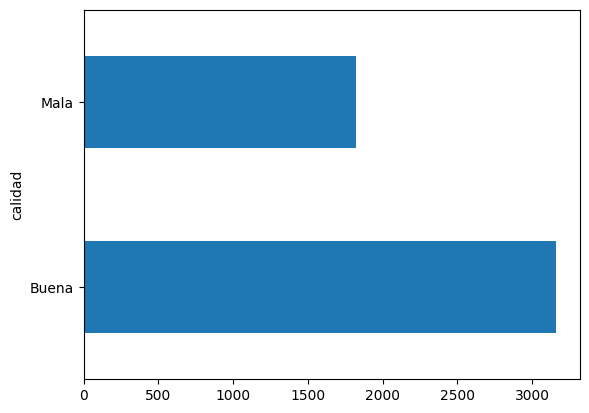

In [9]:
data['calidad'].value_counts().plot(kind='barh')


In [10]:
# Configuración de variables
objetivo='calidad'
predictoras_numericas=['fixed acidity', 'volatile acidity', 'citric acid',
                       'residual sugar', 'chlorides', 'free sulfur dioxide',
                       'total sulfur dioxide', 'density', 'pH', 'sulphates',
                       'alcohol']
predictoras_categoricas_2cat=['tipo']

In [11]:
# No hay necesidad de balanceo de la clase minoritaria

In [12]:
# Creamos variables dummy para convertir  las categorías a números
# data = pd.get_dummies(data, columns=predictoras_categoricas_multicat, drop_first=False, dtype=int)
data = pd.get_dummies(data, columns=predictoras_categoricas_2cat, drop_first=True, dtype=int)
data.head()

# No hay labelencoder-> Variable objetivo ya es numérica

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,calidad,tipo_tinto
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Mala,1
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Mala,1
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Buena,1
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Mala,1
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,Mala,1


In [13]:
# LabelEncoder para la variable objetivo
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data[objetivo] = labelencoder.fit_transform(data[objetivo])
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,calidad,tipo_tinto
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,1,1
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,1,1
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,0,1
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1,1
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4974,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,0,0
4975,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,1,0
4976,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,0,0
4977,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,0,0


# 2. Validación Cruzada







In [14]:
# Validación Cruzada
from sklearn.model_selection import cross_validate, StratifiedKFold

# Dataframe para comparar los modelos
comparacion_CV=pd.DataFrame()
scoring=('f1_macro', 'accuracy','precision_macro', 'recall_macro')
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # Muestreo estratificado

In [15]:
# Se separa variables predictoras y objetivo
X = data.drop(objetivo, axis = 1)
Y = data[objetivo]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4979 entries, 0 to 4978
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4979 non-null   float64
 1   volatile acidity      4979 non-null   float64
 2   citric acid           4979 non-null   float64
 3   residual sugar        4979 non-null   float64
 4   chlorides             4979 non-null   float64
 5   free sulfur dioxide   4979 non-null   float64
 6   total sulfur dioxide  4979 non-null   float64
 7   density               4979 non-null   float64
 8   pH                    4979 non-null   float64
 9   sulphates             4979 non-null   float64
 10  alcohol               4979 non-null   float64
 11  tipo_tinto            4979 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 466.9 KB


# Tree

In [16]:
# Tree
from sklearn import tree
modelTree = tree.DecisionTreeClassifier(criterion='gini', min_samples_leaf=41, max_depth=None)

scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False) # no necesito devlover los modelos
scores=pd.DataFrame(scores) # Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.028726,0.011868,0.636071,0.759070,0.658635,0.777728,0.634906,0.760616,0.637815,0.757685
1,0.025088,0.009487,0.717686,0.753297,0.740964,0.773711,0.720436,0.756604,0.715503,0.750638
2,0.024992,0.009830,0.715215,0.748590,0.744980,0.775720,0.726465,0.763176,0.709348,0.740965
3,0.024369,0.009335,0.683460,0.756679,0.708835,0.774158,0.685210,0.756547,0.682032,0.756812
4,0.024427,0.012136,0.708493,0.749639,0.734940,0.774604,0.713855,0.760042,0.704931,0.743449
5,0.026278,0.016497,0.738994,0.752067,0.759036,0.774604,0.740204,0.758540,0.737898,0.747589
6,0.028126,0.016169,0.727590,0.752796,0.751004,0.772372,0.731636,0.754871,0.724579,0.751006
7,0.024442,0.010111,0.698082,0.747657,0.734940,0.773934,0.717242,0.760193,0.690951,0.740722
8,0.024831,0.009453,0.703619,0.756350,0.736948,0.780852,0.718092,0.767423,0.697194,0.749797
9,0.026330,0.009594,0.714399,0.756171,0.736419,0.774654,0.715784,0.757160,0.713187,0.755253


In [17]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

# Cuidado overfitting. Se trata cuando tengo más de 5 puntos porcentuales de diferencia

,0
fit_time,0.025761
score_time,0.011448
test_f1_macro,0.704361
train_f1_macro,0.753232
test_accuracy,0.730670
train_accuracy,0.775234
test_precision_macro,0.710383
train_precision_macro,0.759517
test_recall_macro,0.701344
train_recall_macro,0.749391


In [18]:
# Se almacena en el df la medida a comparar
comparacion_CV['Tree']=scores['test_f1_macro']
comparacion_CV

,Tree
0,0.636071
1,0.717686
2,0.715215
3,0.683460
4,0.708493
5,0.738994
6,0.727590
7,0.698082
8,0.703619
9,0.714399


# **Random Forest**

In [19]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf= RandomForestClassifier(n_estimators=100,  max_samples=0.9, criterion='gini',
                              max_depth=None, min_samples_leaf=41, random_state=3)

scores = cross_validate(model_rf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) # Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.652438,0.047276,0.691892,0.750220,0.724900,0.778621,0.703240,0.768198,0.686535,0.741569
1,0.795506,0.031021,0.736871,0.747480,0.765060,0.776612,0.750412,0.766280,0.729830,0.738692
2,0.817984,0.037648,0.737155,0.744332,0.767068,0.773711,0.754344,0.762662,0.729083,0.735759
3,0.806048,0.032982,0.733657,0.750088,0.765060,0.778844,0.753004,0.768872,0.725170,0.741227
4,0.591624,0.021459,0.704510,0.744069,0.736948,0.773711,0.717722,0.762923,0.698359,0.735371
5,0.537456,0.020144,0.734229,0.747220,0.763052,0.776612,0.748327,0.766554,0.727083,0.738304
6,0.564352,0.020613,0.708585,0.746001,0.751004,0.775497,0.744112,0.765163,0.698950,0.737166
7,0.576927,0.035425,0.726526,0.742699,0.763052,0.772149,0.755392,0.760659,0.716598,0.734269
8,0.543523,0.023950,0.719998,0.742585,0.753012,0.772595,0.738410,0.761799,0.712182,0.733845
9,0.542458,0.020446,0.714211,0.745403,0.746479,0.774877,0.729981,0.764255,0.707204,0.736660


In [20]:
# Promedios para verificar overfitting comparando medidas en train y test
scores.mean()
#Cuidado overfitting, más de 5 puntos de diferencia

,0
fit_time,0.642832
score_time,0.029096
test_f1_macro,0.720764
train_f1_macro,0.746010
test_accuracy,0.753564
train_accuracy,0.775323
test_precision_macro,0.739494
train_precision_macro,0.764737
test_recall_macro,0.713099
train_recall_macro,0.737286


In [21]:
#Se almacena en el df la medida a comparar
comparacion_CV['RF']=scores['test_f1_macro']
comparacion_CV

,Tree,RF
0,0.636071,0.691892
1,0.717686,0.736871
2,0.715215,0.737155
3,0.683460,0.733657
4,0.708493,0.704510
5,0.738994,0.734229
6,0.727590,0.708585
7,0.698082,0.726526
8,0.703619,0.719998
9,0.714399,0.714211


# KNN

In [22]:
# Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

min_max_scaler.fit(X[predictoras_numericas]) # Ajuste de los parametros: max - min
X[predictoras_numericas]= min_max_scaler.transform(X[predictoras_numericas]) # 70%
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,tipo_tinto
0,0.330579,0.533333,0.000000,0.030675,0.147841,0.083333,0.140553,0.186813,0.372093,0.258427,0.260870,1
1,0.330579,0.453333,0.024096,0.026074,0.137874,0.048611,0.110599,0.190669,0.418605,0.241573,0.260870,1
2,0.611570,0.133333,0.337349,0.019939,0.109635,0.055556,0.124424,0.209948,0.341085,0.202247,0.260870,1
3,0.297521,0.413333,0.000000,0.019939,0.111296,0.034722,0.064516,0.206092,0.612403,0.191011,0.202899,1
4,0.297521,0.386667,0.000000,0.018405,0.109635,0.041667,0.078341,0.206092,0.612403,0.191011,0.202899,1


In [23]:
# Método Perezoso
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=13, metric='euclidean')

scores = cross_validate(model_knn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) # Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.013926,0.043723,0.677576,0.763767,0.706827,0.787994,0.682229,0.776162,0.674624,0.756589
1,0.010113,0.037590,0.736871,0.757597,0.765060,0.783084,0.750412,0.771111,0.729830,0.750132
2,0.011230,0.037498,0.745165,0.751765,0.767068,0.778844,0.749498,0.767165,0.741897,0.743815
3,0.010063,0.038388,0.730214,0.757860,0.757028,0.783530,0.739717,0.771859,0.724666,0.750225
4,0.011532,0.043442,0.700846,0.756805,0.736948,0.783084,0.719443,0.771886,0.693699,0.748838
5,0.010437,0.040665,0.730134,0.760018,0.753012,0.785985,0.733811,0.775345,0.727326,0.751901
6,0.009908,0.038726,0.711806,0.759333,0.746988,0.785093,0.732019,0.773967,0.703940,0.751456
7,0.010975,0.039520,0.717300,0.754445,0.753012,0.780406,0.740516,0.768127,0.708687,0.746987
8,0.010289,0.040569,0.719115,0.759965,0.753012,0.785762,0.739062,0.774875,0.711017,0.751984
9,0.010807,0.042355,0.706959,0.762957,0.740443,0.788041,0.722993,0.777037,0.700122,0.755187


In [24]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,0.010928
score_time,0.040247
test_f1_macro,0.717599
train_f1_macro,0.758451
test_accuracy,0.747940
train_accuracy,0.784182
test_precision_macro,0.730970
train_precision_macro,0.772753
test_recall_macro,0.711581
train_recall_macro,0.750711


In [25]:
# Se almacena en el df la medida a comparar
comparacion_CV['Knn']=scores['test_f1_macro']
comparacion_CV

,Tree,RF,Knn
0,0.636071,0.691892,0.677576
1,0.717686,0.736871,0.736871
2,0.715215,0.737155,0.745165
3,0.683460,0.733657,0.730214
4,0.708493,0.704510,0.700846
5,0.738994,0.734229,0.730134
6,0.727590,0.708585,0.711806
7,0.698082,0.726526,0.717300
8,0.703619,0.719998,0.719115
9,0.714399,0.714211,0.706959


# NN

In [26]:
# Red neuronal

# Solo se configura capas ocultas, no se configura capa de entrada y de salida
# activation -> función activación de la oculta: tanh, logistic, linear, relu
# hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
# learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
# learning_rate_init-> valor tasa de aprendizaje
# momentum-> valor momentum
# max_iter-> iteaciones
# random_state-> semilla para generacion numeros seudoaletorios
from sklearn.neural_network import MLPClassifier
model_rn = MLPClassifier(activation="logistic",hidden_layer_sizes=(50,25,12), learning_rate='constant',
                     learning_rate_init=0.02, momentum= 0.03, max_iter=500, random_state=3)

scores = cross_validate(model_rn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) # Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,4.790203,0.043437,0.704555,0.760929,0.728916,0.780406,0.707150,0.763864,0.702514,0.758501
1,3.745795,0.014930,0.736366,0.759019,0.748996,0.773488,0.732930,0.756287,0.743966,0.762753
2,2.161255,0.014289,0.748912,0.743497,0.759036,0.757420,0.745518,0.740254,0.760033,0.748926
3,2.320403,0.014251,0.699978,0.726430,0.734940,0.760098,0.716298,0.748434,0.693281,0.717656
4,1.895243,0.014688,0.726637,0.742205,0.744980,0.761660,0.725459,0.743070,0.727987,0.741400
5,4.451419,0.042041,0.766541,0.736255,0.789157,0.764561,0.776093,0.749915,0.760467,0.729195
6,0.572253,0.013364,0.740771,0.730562,0.763052,0.748494,0.745032,0.729269,0.737568,0.732058
7,2.822088,0.014388,0.775893,0.744942,0.791165,0.755858,0.774711,0.741449,0.777194,0.754811
8,3.422246,0.013403,0.746879,0.750930,0.771084,0.771926,0.755236,0.754770,0.741567,0.747937
9,2.036690,0.014006,0.745533,0.739734,0.766600,0.760598,0.749007,0.741987,0.742796,0.737834


In [27]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,2.821760
score_time,0.019880
test_f1_macro,0.739207
train_f1_macro,0.743450
test_accuracy,0.759792
train_accuracy,0.763451
test_precision_macro,0.742743
train_precision_macro,0.746930
test_recall_macro,0.738737
train_recall_macro,0.743107


In [28]:
#Se almacena en el df la medida a comparar
comparacion_CV['NN']=scores['test_f1_macro']
comparacion_CV

,Tree,RF,Knn,NN
0,0.636071,0.691892,0.677576,0.704555
1,0.717686,0.736871,0.736871,0.736366
2,0.715215,0.737155,0.745165,0.748912
3,0.683460,0.733657,0.730214,0.699978
4,0.708493,0.704510,0.700846,0.726637
5,0.738994,0.734229,0.730134,0.766541
6,0.727590,0.708585,0.711806,0.740771
7,0.698082,0.726526,0.717300,0.775893
8,0.703619,0.719998,0.719115,0.746879
9,0.714399,0.714211,0.706959,0.745533


# SVM

In [29]:
# SVM
from sklearn.svm import SVC # SVR
model_svm=SVC(kernel='poly', degree=3, C=10, class_weight='balanced')

scores = cross_validate(model_svm, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) # Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,2.595338,0.084429,0.703812,0.757546,0.712851,0.763446,0.703357,0.758133,0.717815,0.777739
1,2.533588,0.049326,0.726391,0.754548,0.732932,0.760991,0.727896,0.754352,0.745288,0.773346
2,2.460689,0.049682,0.746273,0.754943,0.751004,0.762330,0.750468,0.753352,0.770013,0.771426
3,2.111633,0.050051,0.733191,0.753184,0.740964,0.760098,0.732453,0.752340,0.749287,0.770831
4,2.280159,0.050432,0.724157,0.753586,0.730924,0.760768,0.725420,0.752343,0.742541,0.770583
5,3.302062,0.049775,0.763420,0.754101,0.769076,0.761437,0.764099,0.752625,0.784254,0.770722
6,2.044265,0.049700,0.745151,0.751239,0.755020,0.757643,0.742022,0.751332,0.756868,0.770191
7,2.239975,0.049829,0.756446,0.755666,0.767068,0.762330,0.752655,0.755039,0.766362,0.773884
8,2.223080,0.051225,0.718515,0.755914,0.724900,0.762553,0.720805,0.755309,0.737794,0.774189
9,2.646642,0.080858,0.738840,0.749013,0.746479,0.755689,0.737836,0.748817,0.754762,0.767363


In [30]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,2.443743
score_time,0.056531
test_f1_macro,0.735620
train_f1_macro,0.753974
test_accuracy,0.743122
train_accuracy,0.760729
test_precision_macro,0.735701
train_precision_macro,0.753364
test_recall_macro,0.752498
train_recall_macro,0.772027


In [31]:
# Se almacena en el df la medida a comparar
comparacion_CV['SVM']=scores['test_f1_macro']
comparacion_CV

,Tree,RF,Knn,NN,SVM
0,0.636071,0.691892,0.677576,0.704555,0.703812
1,0.717686,0.736871,0.736871,0.736366,0.726391
2,0.715215,0.737155,0.745165,0.748912,0.746273
3,0.683460,0.733657,0.730214,0.699978,0.733191
4,0.708493,0.704510,0.700846,0.726637,0.724157
5,0.738994,0.734229,0.730134,0.766541,0.763420
6,0.727590,0.708585,0.711806,0.740771,0.745151
7,0.698082,0.726526,0.717300,0.775893,0.756446
8,0.703619,0.719998,0.719115,0.746879,0.718515
9,0.714399,0.714211,0.706959,0.745533,0.738840


# XGBoost

In [32]:
# XGBoost: árboles construidos en secuencia, donde cada uno corrige los errores de los anteriores (boosting)
# n_estimators-> número de árboles
# max_depth-> profundidad máxima de cada árbol
# learning_rate-> peso de cada árbol nuevo en la predicción
# min_child_weight-> mínimo de muestras en una hoja, controla el overfitting (similar a min_samples_leaf)
# subsample-> porcentaje de registros que usa cada árbol
# Los árboles no necesitan normalización, por eso usar X normalizado no cambia el resultado
from xgboost import XGBClassifier
model_xgb = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05,
                          min_child_weight=40, subsample=0.8, random_state=3)

scores = cross_validate(model_xgb, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) # Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.378493,0.030164,0.704856,0.761435,0.730924,0.784423,0.709307,0.770622,0.701767,0.755586
1,0.386443,0.014370,0.745165,0.758428,0.767068,0.782415,0.749498,0.768943,0.741897,0.752063
2,0.088630,0.013801,0.764633,0.755322,0.785141,0.779514,0.769761,0.765518,0.760798,0.749130
3,0.095453,0.013929,0.724184,0.761983,0.753012,0.785316,0.735832,0.771998,0.718007,0.755772
4,0.087775,0.013543,0.713309,0.758953,0.736948,0.782415,0.716007,0.768527,0.711173,0.752968
5,0.091988,0.015030,0.750119,0.754839,0.773092,0.779737,0.756948,0.766355,0.745479,0.748141
6,0.104979,0.014310,0.735293,0.751745,0.765060,0.775943,0.751611,0.761147,0.727500,0.745927
7,0.090667,0.014064,0.757551,0.759743,0.787149,0.782861,0.781275,0.768811,0.747235,0.753967
8,0.088350,0.013500,0.733154,0.759434,0.761044,0.783084,0.745199,0.769499,0.726666,0.753237
9,0.124274,0.013982,0.716539,0.757127,0.744467,0.779786,0.725531,0.764729,0.711416,0.752048


In [33]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()
# Cuidado overfitting, más de 5 puntos de diferencia

,0
fit_time,0.153705
score_time,0.015669
test_f1_macro,0.734480
train_f1_macro,0.757901
test_accuracy,0.760390
train_accuracy,0.781549
test_precision_macro,0.744097
train_precision_macro,0.767615
test_recall_macro,0.729194
train_recall_macro,0.751884


In [34]:
# Se almacena en el df la medida a comparar
comparacion_CV['XGB']=scores['test_f1_macro']
comparacion_CV

,Tree,RF,Knn,NN,SVM,XGB
0,0.636071,0.691892,0.677576,0.704555,0.703812,0.704856
1,0.717686,0.736871,0.736871,0.736366,0.726391,0.745165
2,0.715215,0.737155,0.745165,0.748912,0.746273,0.764633
3,0.683460,0.733657,0.730214,0.699978,0.733191,0.724184
4,0.708493,0.704510,0.700846,0.726637,0.724157,0.713309
5,0.738994,0.734229,0.730134,0.766541,0.763420,0.750119
6,0.727590,0.708585,0.711806,0.740771,0.745151,0.735293
7,0.698082,0.726526,0.717300,0.775893,0.756446,0.757551
8,0.703619,0.719998,0.719115,0.746879,0.718515,0.733154
9,0.714399,0.714211,0.706959,0.745533,0.738840,0.716539


# **3. Selección del Modelo**

In [35]:
comparacion_CV

,Tree,RF,Knn,NN,SVM,XGB
0,0.636071,0.691892,0.677576,0.704555,0.703812,0.704856
1,0.717686,0.736871,0.736871,0.736366,0.726391,0.745165
2,0.715215,0.737155,0.745165,0.748912,0.746273,0.764633
3,0.683460,0.733657,0.730214,0.699978,0.733191,0.724184
4,0.708493,0.704510,0.700846,0.726637,0.724157,0.713309
5,0.738994,0.734229,0.730134,0.766541,0.763420,0.750119
6,0.727590,0.708585,0.711806,0.740771,0.745151,0.735293
7,0.698082,0.726526,0.717300,0.775893,0.756446,0.757551
8,0.703619,0.719998,0.719115,0.746879,0.718515,0.733154
9,0.714399,0.714211,0.706959,0.745533,0.738840,0.716539


<Axes: >

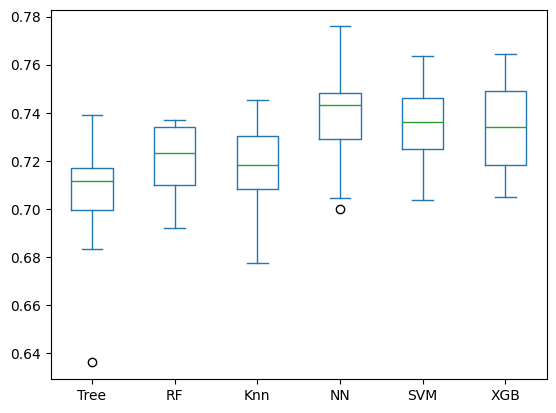

In [36]:
# Resultados de la validación cruzada
comparacion_CV.plot(kind='box')

# 4. Modelo final con todos los datos

**Selección del modelo:**
1. Calidad de los modelos: la red neuronal obtiene el mayor F1 macro promedio (0.739), seguida de SVM (0.736) y XGBoost (0.734). Random Forest (0.721) y Knn (0.718) quedan en un punto intermedio y Tree es el más bajo (0.704).
2. Diagrama de cajas: la red neuronal tiene la mediana más alta (0.743) y la caja más arriba; su único valor atípico (0.700, fold 3) es un fold malo aislado. SVM es el más estable de los mejores (caja angosta, sin atípicos) y XGBoost el más disperso. Las cajas de NN, SVM y XGB se traslapan, la diferencia entre ellos es pequeña. Tree es claramente el peor (atípico en 0.636).
3. Overfitting: ningún modelo supera los 5 puntos de diferencia entre train y test. La red neuronal es la más estable (0.4 puntos), Tree está en el límite (4.9 puntos).
4. Complejidad computacional: Tree es el más liviano y la red neuronal la más costosa de entrenar (alrededor de 3 s por fold), un costo aceptable para este volumen de datos.

Se selecciona la red neuronal por tener el mejor F1 macro, la mediana más alta y la menor diferencia entre train y test. SVM queda como alternativa por su estabilidad.

In [37]:
modelo_final=model_rn

In [38]:
# Si selecciona Tree, RandomForest o XGBoost se desnormaliza con la siguiente instrucción
# Si selecciona Knn, NN, SVM, Reg -> No se desnormaliza y se comenta la siguiente instrucción

# X[predictoras_numericas]= min_max_scaler.inverse_transform(X[predictoras_numericas])

In [39]:
# Modelo final
modelo_final.fit(X, Y)

MLPClassifier(activation='logistic', hidden_layer_sizes=(50, 25, 12),
              learning_rate_init=0.02, max_iter=500, momentum=0.03,
              random_state=3)

In [40]:
# Se guarda el modelo
import pickle
filename = 'modelo-cla-vinos.pkl'
variables=X.columns._values
pickle.dump([modelo_final,labelencoder,variables,min_max_scaler], open(filename, 'wb'))